## Experiment Analysis: Number of Images

In [1]:
# Library imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from collections import Counter
from collections import defaultdict
from scipy.stats import wilcoxon
from scipy import stats

# Visualization settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display the dataframe to fit nicely on the screen
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

#### 1. Data Loading, Processing and Save

Loading the experiment-generated files and converting them into a structured DataFrame for analysis.

In [2]:
# Define the directory containing experiment results
dir_experiments = "../experiments/nimages/results"

# Dictionary to store result file paths for each superpixel/nimage combination
results_files = defaultdict(dict)

# Iterate through each superpixel folder in the results directory
for superpixel_folder in sorted(os.listdir(dir_experiments)):
    superpixel_path = os.path.join(dir_experiments, superpixel_folder)
    # Check if the folder is a valid superpixel folder
    if os.path.isdir(superpixel_path) and superpixel_folder.startswith("super"):
        # Store result files (.csv) found in the folder
        for file in sorted(os.listdir(superpixel_path)):
            if file.endswith("_results.csv") or file.endswith("_layer3_test1-classified-images.cvs"):
                results_files[superpixel_folder][file] = os.path.join(superpixel_path, file)

# List to store extracted results and nimage values
results_data = []
nimages_values = [1]  # Start with 1 image as default

# Extract metrics from each result file
for folder, contents in results_files.items():
    # Parse superpixel and nimage values from folder name
    superpixel = int(folder.split("_")[0].replace('super', ''))
    nimage = int(folder.split("_")[1].replace('images', ''))
    nimages_values.append(nimage)
    for seed, file in contents.items():
        if isinstance(file, str) and file.endswith('_results.csv'):
            results_file = file
            seed_value = int(seed.replace('_results.csv', '').replace('seed', ''))
            with open(results_file, 'r') as f:
                lines = f.readlines()
                if len(lines) >= 4:
                    # Extract accuracy and kappa metrics from the first two lines
                    class1_accuracy, class2_accuracy = map(float, lines[0].strip().split(';')[:2])
                    kappa, global_accuracy = map(float, lines[1].strip().split(';')[:2])
                    # Try to extract nfeat from line 3 or 5 if available
                    if len(lines) > 5 and ': ' in lines[5]:
                        try:
                            nfeat = int(lines[5].strip().split(': ')[1])
                        except (IndexError, ValueError):
                            nfeat = 0
                    elif len(lines) > 3 and ': ' in lines[3]:
                        try:
                            nfeat = int(lines[3].strip().split(': ')[1])
                        except (IndexError, ValueError):
                            nfeat = 0
                    # Append the extracted metrics to the results list
                    results_data.append({
                        'superpixel': superpixel,
                        'nimage': nimage,
                        'seed': seed_value,
                        'class1_accuracy': class1_accuracy,
                        'class2_accuracy': class2_accuracy,
                        'kappa': kappa,
                        'global_accuracy': global_accuracy,
                        'nfeat': nfeat
                    })

# Convert the results list to a DataFrame
df_nimage = pd.DataFrame(results_data)

# Save the DataFrame to a CSV file for further analysis
df_nimage.to_csv('nimages_results_summary.csv', index=False)

In [3]:
df_nimage.head(50)

,superpixel,nimage,seed,class1_accuracy,class2_accuracy,kappa,global_accuracy,nfeat
0,50,2,1011,0.896861,0.988918,0.896081,0.977234,24200
1,50,2,1213,0.847534,0.988266,0.862234,0.970404,24200
2,50,2,123,0.865471,0.985658,0.864379,0.970404,24200
3,50,2,2735,0.860987,0.981747,0.847606,0.966420,24200
4,50,2,42,0.847534,0.979791,0.832108,0.963005,24200
5,50,2,456,0.910314,0.986310,0.894909,0.976665,24200
6,50,2,6854,0.887892,0.990222,0.895269,0.977234,24200
7,50,2,7580,0.865471,0.988266,0.873830,0.972681,24200
8,50,2,789,0.847534,0.983703,0.845823,0.966420,24200
9,50,2,8900,0.865471,0.983051,0.855075,0.968127,24200


#### 2. Analyses and Visualization

In [14]:
# Load the DataFrame with superpixel results
df_nsuper = pd.read_csv('nsuperpixels_results_summary.csv')

# Filter results for superpixel=50 only
df_super50 = df_nsuper[df_nsuper['superpixel'] == 50].copy()

# Calculate mean, standard deviation, and nfeat for superpixel=50
metrics = ['class1_accuracy', 'class2_accuracy', 'kappa', 'global_accuracy']
mean_super50 = df_super50[metrics].mean()
std_super50 = df_super50[metrics].std()
nfeat_super50 = int(df_super50['nfeat'].mean())

# Make a copy of df_nimage and group results by nimage, calculating mean and std for each metric
df_nimage_copy = df_nimage.copy()
metrics = ['class1_accuracy', 'class2_accuracy', 'kappa', 'global_accuracy', 'nfeat']

# Group by number of images and calculate mean and std for each metric (except nfeat)
df_nimage_copy = df_nimage_copy.groupby('nimage')[metrics[:-1]].agg(['mean', 'std']).reset_index()

# Rename columns for easier access (e.g., 'kappa_mean', 'global_accuracy_mean')
df_nimage_copy.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_nimage_copy.columns.values]

# Add the mode of nfeat for each nimage to df_nimage_copy
nfeat_mode = df_nimage.groupby('nimage')['nfeat'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
nfeat_mode = nfeat_mode.sort_index().reset_index()
nfeat_mode.columns = ['nimage', 'nfeat']

df_nimage_copy = df_nimage_copy.merge(nfeat_mode, on='nimage', how='left')

# Add a row for superpixel=50 with the calculated values and nimage=1
df_nimage_copy = pd.concat([df_nimage_copy, pd.DataFrame({
    'nimage': [1],
    'class1_accuracy_mean': [mean_super50['class1_accuracy']],
    'class1_accuracy_std': [std_super50['class1_accuracy']],
    'class2_accuracy_mean': [mean_super50['class2_accuracy']],
    'class2_accuracy_std': [std_super50['class2_accuracy']],
    'kappa_mean': [mean_super50['kappa']],
    'kappa_std': [std_super50['kappa']],
    'global_accuracy_mean': [mean_super50['global_accuracy']],
    'global_accuracy_std': [std_super50['global_accuracy']],
    'nfeat': [nfeat_super50]
})], ignore_index=True)

# Sort the DataFrame by number of images
df_nimage_copy = df_nimage_copy.sort_values(by='nimage').reset_index(drop=True)

# Highlight the best metrics in the summary table
summary_stats_nimage = df_nimage_copy[['nimage', 'class1_accuracy_mean', 'class1_accuracy_std', 'class2_accuracy_mean', 'class2_accuracy_std', 'kappa_mean', 'kappa_std', 'global_accuracy_mean', 'global_accuracy_std']].style.highlight_max(
    subset=['class1_accuracy_mean', 'class2_accuracy_mean', 'kappa_mean', 'global_accuracy_mean'], color='gray'
)

# Format values as percentages for better presentation
# summary_stats_nimage = summary_stats_nimage.format({'kappa_mean': '{:.4%}', 'global_accuracy_mean': '{:.4%}'})

summary_stats_nimage

# versão latex
# Use the already aggregated and flattened df_nimage_copy for LaTeX export
# latex_table = df_nimage_copy.set_index('nimage')[[
#     'class1_accuracy_mean', 'class1_accuracy_std',
#     'class2_accuracy_mean', 'class2_accuracy_std',
#     'kappa_mean', 'kappa_std',
#     'global_accuracy_mean', 'global_accuracy_std'
# ]].to_latex(float_format="%.6f")
# print(latex_table)

,nimage,class1_accuracy_mean,class1_accuracy_std,class2_accuracy_mean,class2_accuracy_std,kappa_mean,kappa_std,global_accuracy_mean,global_accuracy_std
0,1,0.874888,0.024603,0.982855,0.002553,0.860301,0.020929,0.969152,0.004488
1,2,0.869507,0.021912,0.985593,0.003428,0.866731,0.022812,0.970859,0.005025
2,3,0.891928,0.018723,0.985267,0.002665,0.879715,0.019141,0.973420,0.004217
3,4,0.891480,0.022050,0.985528,0.001620,0.880292,0.017390,0.973591,0.003671
4,5,0.603139,0.495038,0.508084,0.511875,0.107193,0.278396,0.520148,0.394971


In [5]:
wilcoxon_results = pd.DataFrame(columns=['nimage1', 'nimage2', 'statistic', 'p_value'])

nimages_unique = sorted(df_nimage['nimage'].unique())
for i in range(len(nimages_unique)):
    for j in range(i + 1, len(nimages_unique)):
        n1 = nimages_unique[i]
        n2 = nimages_unique[j]
        
        data_n1 = df_nimage[df_nimage['nimage'] == n1]['global_accuracy']
        data_n2 = df_nimage[df_nimage['nimage'] == n2]['global_accuracy']
        
        if len(data_n1) == len(data_n2) and len(data_n1) > 0:
            statistic, p_value = wilcoxon(data_n1, data_n2)
            wilcoxon_results.loc[len(wilcoxon_results)] = {
                'nimage1': n1,
                'nimage2': n2,
                'statistic': statistic,
                'p_value': p_value
            }

print("Resultados do teste de Wilcoxon entre nimages:")
print(wilcoxon_results)

significant = wilcoxon_results[wilcoxon_results['p_value'] < 0.05]
print("Comparações com diferença estatisticamente significativa:")
print(significant)
print(f"Total de comparações significativas: {len(significant)} de {len(wilcoxon_results)}")


Resultados do teste de Wilcoxon entre nimages:
   nimage1  nimage2  statistic   p_value
0        2        3       15.0  0.222656
1        2        4       12.0  0.125000
2        2        5        1.0  0.003906
3        3        4       13.0  0.937500
4        3        5        0.0  0.001953
5        4        5        1.0  0.003906
Comparações com diferença estatisticamente significativa:
   nimage1  nimage2  statistic   p_value
2        2        5        1.0  0.003906
4        3        5        0.0  0.001953
5        4        5        1.0  0.003906
Total de comparações significativas: 3 de 6


In [15]:
# mostrar o numero de features para cada nimage
df_nimage[['nimage', 'nfeat']].drop_duplicates().sort_values(by='nimage')

,nimage,nfeat
0,2,24200
10,3,36300
20,4,48400
30,5,1210
32,5,60500


In [21]:
# Path to the experiments directory for nimages
dir_experiments_nimages = "../experiments/nimages/results"

# Dicionários separados para nimages
results_files_pred_nimages = defaultdict(dict)
nimage_images = defaultdict(dict)

# Traverse the experiments directory for nimages
for nimage_folder in sorted(os.listdir(dir_experiments_nimages)):
    nimage_path = os.path.join(dir_experiments_nimages, nimage_folder)
    # Ignorar pastas que contenham '5inames' no nome
    if 'super50_5images' in nimage_folder:
        continue
    if os.path.isdir(nimage_path) and nimage_folder.startswith("super"):
        # Armazena arquivos de resultados
        for file in sorted(os.listdir(nimage_path)):
            if file.endswith("layer3_test1-classified-images.csv"):
                seed = int(file.split('_')[0].replace('seed', ''))
                nimage = int(nimage_folder.split("_")[1].replace('images', ''))
                with open(os.path.join(nimage_path, file), 'r') as f:
                    lines = f.readlines()
                    correct_class = []
                    predicted_class = []
                    img_name = []
                    for line in lines:
                        parts = line.strip().split(';')
                        if len(parts) >= 3:
                            img_name.append(parts[0])
                            correct_class.append(int(parts[1]))
                            predicted_class.append(int(parts[2]))
                results_files_pred_nimages[nimage][seed] = {'img_name': img_name, 'correct': correct_class, 'predicted': predicted_class}

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# montar matriz de confusão para cada nimage e semente
confusion_matrices_nimage = {}
for nimage, seeds_data in results_files_pred_nimages.items():
    confusion_matrices_nimage[nimage] = {}
    for seed, data in seeds_data.items():
        correct = np.array(data['correct'])
        predicted = np.array(data['predicted'])
        cm = pd.crosstab(correct, predicted, rownames=['Actual'], colnames=['Predicted'], dropna=False)
        confusion_matrices_nimage[nimage][seed] = cm

evaluation_metrics_nimage = []
for nimage, seeds_data in results_files_pred_nimages.items():
    for seed, data in seeds_data.items():
        y_true = data['correct']
        y_pred = data['predicted']
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
        tn, fp, fn, tp = cm.ravel()
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = f1_score(y_true, y_pred, average='macro')
        evaluation_metrics_nimage.append({
            "nimage": nimage,
            "seed": seed,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "specificity": specificity
        })

df_metrics_nimage = pd.DataFrame(evaluation_metrics_nimage)
df_metrics_nimage_mean = df_metrics_nimage.groupby('nimage').mean().reset_index()
df_metrics_nimage_mean

# mostrar codigo latex
latex_table_nimage = df_metrics_nimage_mean.to_latex(float_format="%.6f")
print(latex_table_nimage)

\begin{tabular}{lrrrrrrr}
\toprule
 & nimage & seed & accuracy & precision & recall & f1 & specificity \\
\midrule
0 & 2 & 2970.300000 & 0.970859 & 0.939519 & 0.927550 & 0.933362 & 0.869507 \\
1 & 3 & 2970.300000 & 0.973421 & 0.941184 & 0.938598 & 0.939857 & 0.891928 \\
2 & 4 & 2970.300000 & 0.973591 & 0.941886 & 0.938504 & 0.940145 & 0.891480 \\
\bottomrule
\end{tabular}



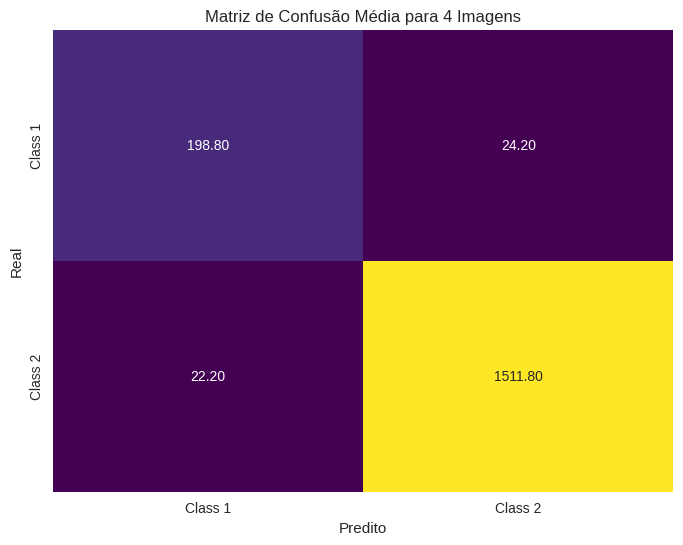

In [31]:
# mostrar matriz de confusão média para nimage=4 usando seaborn
nimage_to_display = 4
class_names = ['Class 1', 'Class 2']
if nimage_to_display in confusion_matrices_nimage:
    # Calcular a matriz de confusão média entre todas as sementes
    cms = list(confusion_matrices_nimage[nimage_to_display].values())
    mean_cm = sum(cm.values for cm in cms) / len(cms)
    plt.figure(figsize=(8, 6))
    sns.heatmap(mean_cm, annot=True, fmt=".2f", cmap="viridis", cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Matriz de Confusão Média para {nimage_to_display} Imagens")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()